In [1]:
!pip install -q trimesh networkx

import trimesh
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

print("Setup done. Trimesh version:", trimesh.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 11.8 MB/s eta 0:00:00
Setup done. Trimesh version: 5.1.0


In [2]:
# Build a synthetic test part: a wide base, a thin neck, then a wide overhanging cap
# This gives us a known area jump and a known overhang to check the scanner against

base = trimesh.creation.cylinder(radius=20, height=10, sections=32)
base.apply_translation([0, 0, 5])

neck = trimesh.creation.cylinder(radius=4, height=15, sections=32)
neck.apply_translation([0, 0, 17.5])

cap = trimesh.creation.cylinder(radius=18, height=8, sections=32)
cap.apply_translation([0, 0, 29])

test_part = trimesh.util.concatenate([base, neck, cap])
test_part.export('test_part.stl')

print("Vertices:", len(test_part.vertices))
print("Bounds (mm):", test_part.bounds)
print("Watertight:", test_part.is_watertight)

Vertices: 198
Bounds (mm): [[-20. -20.   0.]
 [ 20.  20.  33.]]
Watertight: True


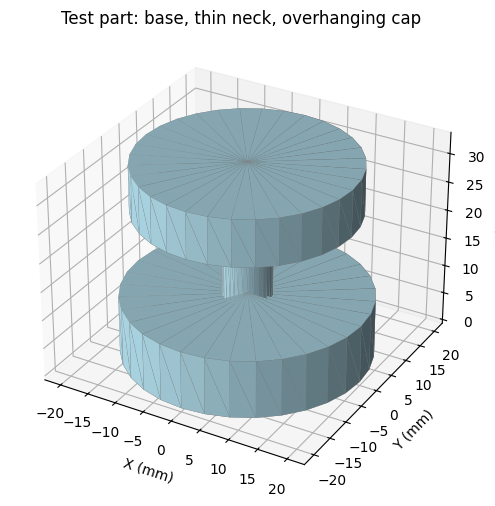

In [3]:
# Plot the test part so we can see the neck and overhang by eye before slicing it
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot_trisurf(
    test_part.vertices[:, 0],
    test_part.vertices[:, 1],
    test_part.vertices[:, 2],
    triangles=test_part.faces,
    color='lightblue',
    edgecolor='gray',
    linewidth=0.1
)

ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
ax.set_title('Test part: base, thin neck, overhanging cap')
plt.show()

In [4]:
# Slice the mesh into horizontal layers and record each layer's cross section
# This mimics what a slicer does before generating a print path

layer_height = 0.5  # mm, a typical resin printer layer thickness
z_min, z_max = test_part.bounds[0][2], test_part.bounds[1][2]
z_levels = np.arange(z_min + layer_height, z_max, layer_height)

layers = []
for z in z_levels:
    section = test_part.section(plane_origin=[0, 0, z], plane_normal=[0, 0, 1])
    if section is None:
        layers.append({'z': z, 'area': 0, 'polygon': None})
        continue
    planar, _ = section.to_planar()
    area = planar.area
    layers.append({'z': z, 'area': area, 'polygon': planar})

print("Total layers:", len(layers))
print("First layer area (mm^2):", layers[0]['area'])
print("Last layer area (mm^2):", layers[-1]['area'])

/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:

Total layers: 65
First layer area (mm^2): 1248.578060903221
Last layer area (mm^2): 1011.3482293316086


/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/2285366279.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()


In [5]:
# Flag layers where cross sectional area jumps sharply from the layer below
# A large area increase means the new layer isn't well supported by the one under it

areas = np.array([l['area'] for l in layers])
area_ratio = np.ones(len(areas))
area_ratio[1:] = areas[1:] / np.maximum(areas[:-1], 1e-6)

risk_threshold = 1.5  # area more than 50 percent bigger than the layer below is flagged
area_risk = area_ratio > risk_threshold

for i, l in enumerate(layers):
    l['area_ratio'] = area_ratio[i]
    l['area_risk'] = bool(area_risk[i])

print("Layers flagged for area jump risk:", area_risk.sum())
flagged_z = [layers[i]['z'] for i in range(len(layers)) if area_risk[i]]
print("Flagged heights (mm):", flagged_z)

Layers flagged for area jump risk: 1
Flagged heights (mm): [np.float64(25.0)]


In [6]:
# Estimate overhang by comparing each layer's centroid-to-edge reach against the layer below
# A layer that extends further outward than the one beneath it is an overhang

def max_radius(polygon):
    if polygon is None or len(polygon.polygons_full) == 0:
        return 0
    coords = np.array(polygon.polygons_full[0].exterior.coords)
    centroid = coords.mean(axis=0)
    dists = np.linalg.norm(coords - centroid, axis=1)
    return dists.max()

radii = np.array([max_radius(l['polygon']) for l in layers])
radius_growth = np.zeros(len(radii))
radius_growth[1:] = radii[1:] - radii[:-1]

overhang_threshold = 2.0  # mm of outward growth per layer height, tune this per printer
overhang_risk = radius_growth > overhang_threshold

for i, l in enumerate(layers):
    l['radius'] = radii[i]
    l['radius_growth'] = radius_growth[i]
    l['overhang_risk'] = bool(overhang_risk[i])

print("Layers flagged for overhang risk:", overhang_risk.sum())
flagged_z = [layers[i]['z'] for i in range(len(layers)) if overhang_risk[i]]
print("Flagged heights (mm):", flagged_z)

Layers flagged for overhang risk: 1
Flagged heights (mm): [np.float64(25.0)]


In [7]:
# Combine area jump and overhang signals into one 0 to 1 risk score per layer
# Weighted equally for now, could be tuned against real print outcomes later

max_area_ratio = area_ratio.max()
max_radius_growth = max(radius_growth.max(), 1e-6)

area_score = np.clip(area_ratio - 1, 0, None) / max(max_area_ratio - 1, 1e-6)
overhang_score = np.clip(radius_growth, 0, None) / max_radius_growth

composite_risk = 0.5 * area_score + 0.5 * overhang_score

for i, l in enumerate(layers):
    l['composite_risk'] = composite_risk[i]

worst_idx = np.argmax(composite_risk)
print("Highest risk layer at z =", layers[worst_idx]['z'], "mm")
print("Composite risk score:", round(composite_risk[worst_idx], 3))

Highest risk layer at z = 25.0 mm
Composite risk score: 1.0


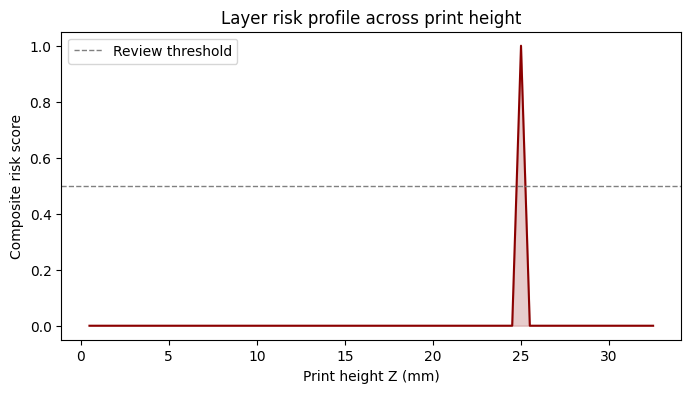

In [8]:
# Plot composite risk score against print height, this is the kind of chart
# a slicer report or print log would show for a flagged part

z_vals = [l['z'] for l in layers]
risk_vals = [l['composite_risk'] for l in layers]

plt.figure(figsize=(8, 4))
plt.plot(z_vals, risk_vals, color='darkred')
plt.fill_between(z_vals, risk_vals, color='darkred', alpha=0.2)
plt.xlabel('Print height Z (mm)')
plt.ylabel('Composite risk score')
plt.title('Layer risk profile across print height')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Review threshold')
plt.legend()
plt.show()

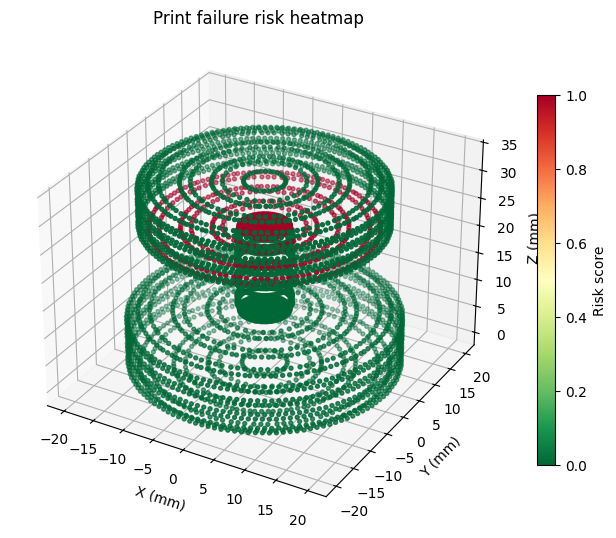

Risk value range: 0.0 to 1.0
Faces above 0.3 risk: 1024 out of 6144


In [13]:
# Plot each triangle's center point as a dot colored by its risk score
# Scatter plots handle color mapping reliably, unlike plot_trisurf's surface shading

face_centers = fine_mesh.triangles_center

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    face_centers[:, 0],
    face_centers[:, 1],
    face_centers[:, 2],
    c=face_risk_fine,
    cmap='RdYlGn_r',
    vmin=0,
    vmax=1,
    s=8
)

fig.colorbar(scatter, ax=ax, shrink=0.6, label='Risk score')
ax.set_title('Print failure risk heatmap')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
plt.show()

print("Risk value range:", face_risk_fine.min(), "to", face_risk_fine.max())
print("Faces above 0.3 risk:", (face_risk_fine > 0.3).sum(), "out of", len(face_risk_fine))

In [14]:
# Second test geometry: a tall post with a horizontal arm sticking out sideways
# This tests overhang detection on a shape where risk isn't just about area growing upward

post = trimesh.creation.cylinder(radius=6, height=30, sections=24)
post.apply_translation([0, 0, 15])

arm = trimesh.creation.box(extents=[25, 6, 6])
arm.apply_translation([12, 0, 27])

cantilever_part = trimesh.util.concatenate([post, arm])
cantilever_part.export('cantilever_part.stl')

print("Watertight:", cantilever_part.is_watertight)
print("Bounds (mm):", cantilever_part.bounds)

Watertight: True
Bounds (mm): [[-6.  -6.   0. ]
 [24.5  6.  30. ]]


In [15]:
# Wrap slicing, area jump, overhang, and composite scoring into one function
# so we can run the full analysis on any mesh with one call

def analyze_print_risk(mesh, layer_height=0.5, area_threshold=1.5, overhang_threshold=2.0):
    z_min, z_max = mesh.bounds[0][2], mesh.bounds[1][2]
    z_levels = np.arange(z_min + layer_height, z_max, layer_height)

    layers = []
    for z in z_levels:
        section = mesh.section(plane_origin=[0, 0, z], plane_normal=[0, 0, 1])
        if section is None:
            layers.append({'z': z, 'area': 0, 'polygon': None})
            continue
        planar, _ = section.to_planar()
        layers.append({'z': z, 'area': planar.area, 'polygon': planar})

    areas = np.array([l['area'] for l in layers])
    area_ratio = np.ones(len(areas))
    area_ratio[1:] = areas[1:] / np.maximum(areas[:-1], 1e-6)

    def max_radius(polygon):
        if polygon is None or len(polygon.polygons_full) == 0:
            return 0
        coords = np.array(polygon.polygons_full[0].exterior.coords)
        centroid = coords.mean(axis=0)
        return np.linalg.norm(coords - centroid, axis=1).max()

    radii = np.array([max_radius(l['polygon']) for l in layers])
    radius_growth = np.zeros(len(radii))
    radius_growth[1:] = radii[1:] - radii[:-1]

    area_score = np.clip(area_ratio - 1, 0, None) / max(np.clip(area_ratio - 1, 0, None).max(), 1e-6)
    overhang_score = np.clip(radius_growth, 0, None) / max(np.clip(radius_growth, 0, None).max(), 1e-6)
    composite_risk = 0.5 * area_score + 0.5 * overhang_score

    z_vals = [l['z'] for l in layers]
    fine_mesh = mesh.subdivide().subdivide()
    face_risk = np.interp(fine_mesh.triangles_center[:, 2], z_vals, composite_risk)

    return {
        'z_vals': z_vals,
        'composite_risk': composite_risk,
        'fine_mesh': fine_mesh,
        'face_risk': face_risk
    }

print("Function defined.")

Function defined.


/tmp/ipykernel_1952/4078457436.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/4078457436.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/4078457436.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/4078457436.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/4078457436.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/4078457436.py:14: DeprecationWarning: DEPRECATED: replace `path.to_planar`->`path.to_2D), removal 1/1/2026
  planar, _ = section.to_planar()
/tmp/ipykernel_1952/4078457436.py:

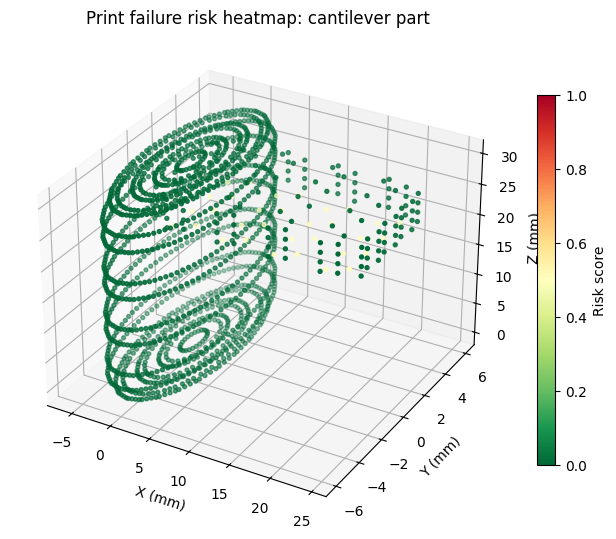

Highest risk height (mm): 24.0


In [16]:
# Run the full analysis on the cantilever part and plot the risk heatmap

result = analyze_print_risk(cantilever_part)

face_centers = result['fine_mesh'].triangles_center
face_risk = result['face_risk']

fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    face_centers[:, 0],
    face_centers[:, 1],
    face_centers[:, 2],
    c=face_risk,
    cmap='RdYlGn_r',
    vmin=0,
    vmax=1,
    s=8
)

fig.colorbar(scatter, ax=ax, shrink=0.6, label='Risk score')
ax.set_title('Print failure risk heatmap: cantilever part')
ax.set_xlabel('X (mm)')
ax.set_ylabel('Y (mm)')
ax.set_zlabel('Z (mm)')
plt.show()

worst_z = result['z_vals'][np.argmax(result['composite_risk'])]
print("Highest risk height (mm):", worst_z)

In [21]:
# Build a clean tabular summary of the full project run, for the README and writeup
import pandas as pd

summary_rows = []
for name, res in [('Neck to cap overhang part', test_results), ('Cantilever arm part', cantilever_results)]:
    peak_idx = np.argmax(res['composite_risk'])
    summary_rows.append({
        'Test part': name,
        'Total layers': len(res['z_vals']),
        'Peak risk height (mm)': round(res['z_vals'][peak_idx], 2),
        'Peak risk score': round(res['composite_risk'][peak_idx], 3),
        'Layers above 0.5 risk': int((res['composite_risk'] > 0.5).sum())
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

,Test part,Total layers,Peak risk height (mm),Peak risk score,Layers above 0.5 risk
0,Neck to cap overhang part,65,25.0,1.0,1
1,Cantilever arm part,59,24.0,0.5,0
